## Questão 6 - Dimensão de calendário

### Cenário

O Sr. Almir quer saber. 'Qual é o dia da semana (Segunda, Terça ... ) que temos a pior média de vendas?' para decidir se vale a pena fechar a loja nesses dias. 

Um estagiário fez um GROUP BY dia_semana direto na tabela de vendas e disse que a Terça-feira era ótima, com média de R$ 5.000,00. 

O problema: O estagiário esqueceu que em muitas terças-feiras a loja abriu mas vendeu zero. Como esses dias nao existem na tabela de vendas (`vendas_2023_2024.csv`), eles foram ignorados no cálculo da média, inflando o resultado. Precisamos corrigir isso utilizando um calendario de datas (dimensão de datas)

### Premissas obrigatórias:

- O periodo de analise deve considerar todas as datas entre a menor e a maior data_venda presentes no arquivo.
- A loja esteve aberta em todos os dias do periodo (inclusive fins de semana).
- Dias sem registro na tabela de vendas devem ser considerados como `valor_venda = 0`.
- “Vendas diarias" correspondem à soma de valor_venda por dia.
- A media de vendas por dia da semana deve considerar todos os dias do calendario, inclusive
os dias sem venda.
- O nome do dia da semana deve ser apresentado em portugués (Segunda-feira,
Terça-feira, etc.).

### Tarefa:

1. Construa uma dimensão de datas utilizando sql 
2. Cruze a dimensão de datas com a tabela de vendas para análise (nao esqueça de considerar os dias sem vendas).

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
vendas = pd.read_csv('../datasets/processed/vendas_normalizadas.csv')
vendas['sale_date'] = pd.to_datetime(vendas['sale_date'])

vendas.info()

<class 'pandas.DataFrame'>
RangeIndex: 9895 entries, 0 to 9894
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   id          9895 non-null   int64         
 1   id_client   9895 non-null   int64         
 2   id_product  9895 non-null   int64         
 3   qtd         9895 non-null   int64         
 4   total       9895 non-null   float64       
 5   sale_date   9895 non-null   datetime64[us]
dtypes: datetime64[us](1), float64(1), int64(4)
memory usage: 464.0 KB


In [3]:
vendas.head()

,id,id_client,id_product,qtd,total,sale_date
0,0,42,105,11,3405.0,2023-09-10
1,1,3,136,9,16873.9,2024-09-15
2,2,25,139,7,9475.3,2024-08-13
3,4,20,23,5,55893.0,2023-02-03
4,5,8,57,4,451403.9,2024-02-12


> 1. Dimensão de datas 

In [4]:
# Estabelecendo o período de análise
data_inicio = vendas['sale_date'].min()
data_fim = vendas['sale_date'].max()

# Criando a sequência de datas (Dimensão Calendário)
data = pd.date_range(start=data_inicio, end=data_fim, freq='D')
calendario = pd.DataFrame({'data_referencia': data})

print(f"Período analisado: {data_inicio.date()} até {data_fim.date()}")
print(f"Total de dias no calendário: {len(data)}")

Período analisado: 2023-01-01 até 2024-12-31
Total de dias no calendário: 731


> 2. Cruze a dimensão de datas com a tabela de vendas para análise (nao esqueça de considerar os dias sem vendas)

In [5]:
# Define como vai ser exibido os números float de forma global
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

In [6]:
# Agrupar vendas por dia somando o faturamento total
df_vendas_diarias = vendas.groupby('sale_date')['total'].sum().reset_index()

# Merge (Left Join) para garantir que todos os dias do calendário existam no resultado
df_analise = pd.merge(calendario, df_vendas_diarias, 
                      left_on='data_referencia', 
                      right_on='sale_date', 
                      how='left')

# Preenchendo dias sem vendas com zero (Premissa obrigatória)
df_analise['total'] = df_analise['total'].fillna(0)

# Mapeando os dias da semana para português
dias_traducao = {
    'Monday': 'Segunda-feira', 'Tuesday': 'Terça-feira', 'Wednesday': 'Quarta-feira',
    'Thursday': 'Quinta-feira', 'Friday': 'Sexta-feira', 'Saturday': 'Sábado', 'Sunday': 'Domingo'
}
df_analise['dia_semana'] = df_analise['data_referencia'].dt.day_name().map(dias_traducao)

df_analise.head()

,data_referencia,sale_date,total,dia_semana
0,2023-01-01,2023-01-01,"4,207,939.25",Domingo
1,2023-01-02,2023-01-02,"5,102,799.80",Segunda-feira
2,2023-01-03,2023-01-03,"8,299,127.05",Terça-feira
3,2023-01-04,2023-01-04,"4,707,759.40",Quarta-feira
4,2023-01-05,2023-01-05,"5,525,706.90",Quinta-feira


In [7]:
# Cálculo da média real
media_dia = df_analise.groupby('dia_semana')['total'].mean().reset_index()

# Ordenando para identificar o pior desempenho
media_dia = media_dia.sort_values(by='total', ascending=True)

# Exibindo o resultado formatado
pd.options.display.float_format = 'R$ {:,.2f}'.format
print("Ranking de Vendas por Dia da Semana (Média Real):")
print(media_dia)

Ranking de Vendas por Dia da Semana (Média Real):
      dia_semana           total
0        Domingo R$ 3,319,503.57
3  Segunda-feira R$ 3,465,137.71
1   Quarta-feira R$ 3,535,265.63
2   Quinta-feira R$ 3,626,232.44
6    Terça-feira R$ 3,627,045.76
5         Sábado R$ 3,710,540.55
4    Sexta-feira R$ 3,715,003.41


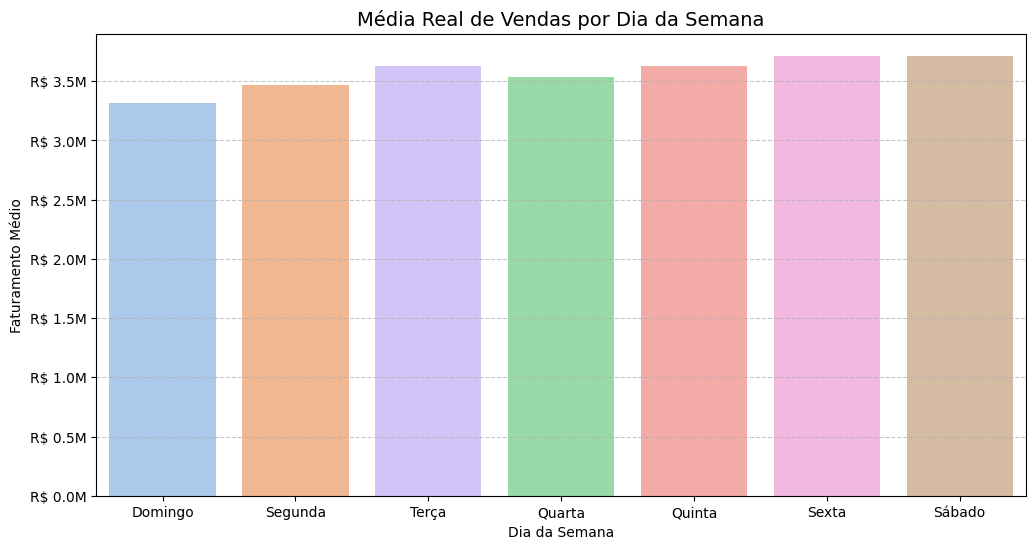

In [ ]:
# Preparação para o gráfico
media_dia['dia_semana_curto'] = media_dia['dia_semana'].str.replace('-feira', '')
ordem = ['Domingo', 'Segunda', 'Terça', 'Quarta', 'Quinta', 'Sexta', 'Sábado']

plt.figure(figsize=(12, 6))
sns.barplot(data=media_dia, 
            x='dia_semana_curto', 
            y='total', 
            palette='pastel', 
            order=ordem,
            hue='dia_semana_curto',
            legend=False)

# Formatação do eixo Y para Milhões (M)
def format_millions(x, pos):
    return f'R$ {x/1e6:.1f}M'

plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(format_millions))

plt.title('Média Real de Vendas por Dia da Semana', fontsize=14)
plt.xlabel('Dia da Semana')
plt.ylabel('Faturamento Médio')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.savefig("../notebooks/plots/grafico_media_vendas_dia.png")
plt.show()

> SQL

In [ ]:
import sqlite3

# Carregar o ficheiro CSV com o pandas
df_vendas = pd.read_csv('../datasets/processed/vendas_normalizadas.csv')

# Criar uma ligação a uma base de dados SQLite na memória
conn = sqlite3.connect(':memory:')

# Enviar os dados do DataFrame para a base de dados SQLite
df_vendas.to_sql('vendas', conn, index=False)

# Dimensão de Calendário via SQLite
query_q6 = """
WITH RECURSIVE Limites AS (
    -- 1. Encontrar a primeira e a última data da base de dados
    SELECT 
        DATE(MIN(sale_date)) AS min_data,
        DATE(MAX(sale_date)) AS max_data
    FROM vendas
),
DimCalendario(data_calendario) AS (
    -- 2. Criar o calendário recursivamente somando +1 dia
    SELECT min_data FROM Limites
    UNION ALL
    SELECT DATE(data_calendario, '+1 day')
    FROM DimCalendario
    WHERE data_calendario < (SELECT max_data FROM Limites)
),
VendasDiarias AS (
    -- 3. Agregar as vendas por dia
    SELECT 
        DATE(sale_date) AS data_venda,
        SUM(total) AS valor_venda_dia
    FROM vendas
    GROUP BY DATE(data_venda)
),
VendasComCalendario AS (
    -- 4. Cruzar o calendário contínuo com as vendas diárias
    SELECT 
        c.data_calendario,
        CAST(strftime('%w', c.data_calendario) AS INTEGER) AS dia_semana_num,
        COALESCE(v.valor_venda_dia, 0) AS valor_venda
    FROM DimCalendario c
    LEFT JOIN VendasDiarias v ON c.data_calendario = v.data_venda
)

-- 5. Calcular a média final e traduzir os dias da semana
SELECT 
    CASE dia_semana_num
        WHEN 0 THEN 'Domingo'
        WHEN 1 THEN 'Segunda-feira'
        WHEN 2 THEN 'Terça-feira'
        WHEN 3 THEN 'Quarta-feira'
        WHEN 4 THEN 'Quinta-feira'
        WHEN 5 THEN 'Sexta-feira'
        WHEN 6 THEN 'Sábado'
    END AS dia_semana,
    ROUND(AVG(valor_venda), 2) AS media_vendas,
    COUNT(data_calendario) AS total_dias_avaliados
FROM VendasComCalendario
GROUP BY dia_semana_num, dia_semana
ORDER BY media_vendas ASC;
"""

print("\n--- Resultado da Questão 6 (Pior dia de vendas) ---")
# O pandas executa a consulta na base de dados SQLite e mostra o ecrã de forma elegante
display(pd.read_sql_query(query_q6, conn))

# Fechar a ligação para libertar memória
conn.close()


--- Resultado da Questão 6 (Pior dia de vendas) ---


,dia_semana,media_vendas,total_dias_avaliados
0,Domingo,"R$ 3,319,503.57",105
1,Segunda-feira,"R$ 3,465,137.71",105
2,Quarta-feira,"R$ 3,535,265.63",104
3,Quinta-feira,"R$ 3,626,232.44",104
4,Terça-feira,"R$ 3,627,045.76",105
5,Sábado,"R$ 3,710,540.55",104
6,Sexta-feira,"R$ 3,715,003.41",104
